## Cell 1: Dependencies & Version Fix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Force install compatible versions to avoid the 'ufunc' error
!pip install "numpy<2.0" "pandas<2.2" "scipy<1.13" --force-reinstall
!pip install yfinance pandas matplotlib scikit-learn torch pandas_ta


  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.1.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached scipy-1.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached pandas-2.1.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (11.7 MB)
Using cached scipy-1.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.8 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 k

INFO: pip is looking at multiple versions of pandas-ta to determine which version is compatible with other requirements. This could take a while.
  Using cached pandas_ta-0.4.67b0-py3-none-any.whl.metadata (2.2 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
INFO: pip is still looking at multiple versions of pandas-ta to determine which version is compatible with other requirements. This could take a while.
  Using cached scikit_learn-1.7.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached scikit_learn-1.7.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (17 kB)
  Using cached scikit_learn-1.6.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014

## Cell 2: Data Acquisition + Feature Engineering  

In [1]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# --- Configuration ---
TICKER_SYMBOL = 'AAPL'
START_DATE = (datetime.now() - pd.DateOffset(years=5)).strftime('%Y-%m-%d')
END_DATE = datetime.now().strftime('%Y-%m-%d')
FILE_NAME = 'AAPL_featured_data.csv'

print("Downloading data...")
df_raw = yf.download(TICKER_SYMBOL, start=START_DATE, end=END_DATE, auto_adjust=True)
df = df_raw[['Close', 'Volume']].copy()

# --- FEATURE ENGINEERING (Rolling 50 Days) ---
print("Calculating 50-day indicators...")
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

df['Volatility'] = df['Close'].rolling(window=50).std()

df = df.dropna()
df.to_csv(FILE_NAME)
print(f"SUCCESS! Data downloaded and indicators calculated.")


[*********************100%***********************]  1 of 1 completed

Calculating 50-day indicators...
SUCCESS! Data downloaded and indicators calculated.


## Cell 3: Load and Preprocess Data

In [2]:
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

# Load the data we just created in Cell 2
df = pd.read_csv(FILE_NAME, index_col=0, parse_dates=True)

# Cleaning block
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()

# Normalization
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values.astype('float32'))

# Sliding Window
def create_multivariate_sequences(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 50
X, y = create_multivariate_sequences(scaled_data, WINDOW_SIZE)

# Split
train_size = int(len(X) * 0.8)
X_train = torch.FloatTensor(X[:train_size])
y_train = torch.FloatTensor(y[:train_size]).view(-1, 1)
X_test = torch.FloatTensor(X[train_size:])
y_test = torch.FloatTensor(y[train_size:]).view(-1, 1)

print(f"Preprocessing Complete. X_train shape: {X_train.shape}")


Preprocessing Complete. X_train shape: torch.Size([924, 50, 6])


/tmp/ipykernel_939/3618327596.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(FILE_NAME, index_col=0, parse_dates=True)


## Cell 4: GRU Model Architecture

In [3]:
import torch.nn as nn

class StockGRU(nn.Module):
    def __init__(self, input_size=6, hidden_size=128, num_layers=2):
        super(StockGRU, self).__init__()
        # GRU instead of LSTM
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_step = gru_out[:, -1, :]
        return self.linear(last_step)

print("GRU Model Defined.")


GRU Model Defined.


## Cell 5: Training Loop


In [4]:
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

model = StockGRU().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 150
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch+1) % 25 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.6f}')

print("Training Finished!")


Epoch [25/150], Loss: 0.000565
Epoch [50/150], Loss: 0.000424
Epoch [75/150], Loss: 0.000501
Epoch [100/150], Loss: 0.000410
Epoch [125/150], Loss: 0.000385
Epoch [150/150], Loss: 0.000334
Training Finished!


## Cell 6: Final Result Plot

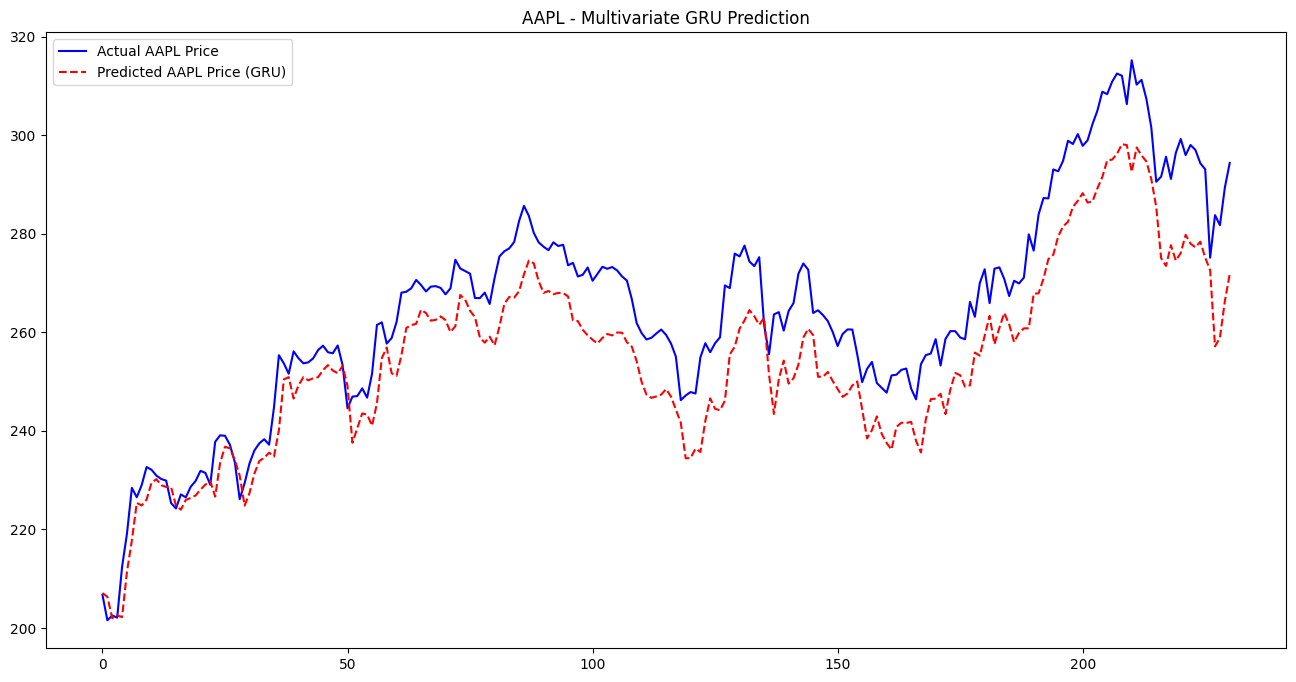

In [5]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    predictions = model(X_test).cpu().numpy()
    actuals = y_test.cpu().numpy()

def inverse_transform_close(vals, scaler):
    dummy = np.zeros((len(vals), 6))
    dummy[:, 0] = vals.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

predictions = inverse_transform_close(predictions, scaler)
actuals = inverse_transform_close(actuals, scaler)

plt.figure(figsize=(16, 8))
plt.plot(actuals, label='Actual AAPL Price', color='blue')
plt.plot(predictions, label='Predicted AAPL Price (GRU)', color='red', linestyle='--')
plt.title('AAPL - Multivariate GRU Prediction')
plt.legend()
plt.show()
